# 🛒 E-Commerce Customer Analytics using PySpark

## 1. Project Overview

In this project, we use **PySpark in Databricks** to load, inspect, clean, transform, and analyze e-commerce customer data. The project focuses on understanding customer characteristics, segments, regions, and acquisition costs while practicing core Spark DataFrame operations, Spark SQL, window functions, and data storage with Delta tables.


## 2. Import Libraries

In this section, we import the PySpark libraries required for data loading, transformation, analysis, and working with Spark SQL.



In [0]:
from pyspark.sql import functions as f
from pyspark.sql.window import Window

## 3. Data Loading and Initial Exploration

In this section, we load the e-commerce customer dataset into a PySpark DataFrame and examine its schema and structure before performing data quality checks and transformations.


In [0]:
df= spark.read.csv('/Volumes/workspace/default/my_volume/customer_master.csv',header=True , inferSchema=True)
df.show(5)

+-----------+-------------+------------+------+----------------+--------------+--------------+----------------+------+--------------------+-------------------------+
|customer_id|customer_name|customer_age|gender|customer_segment| customer_city|customer_state|customer_country|region|customer_postal_code|customer_acquisition_cost|
+-----------+-------------+------------+------+----------------+--------------+--------------+----------------+------+--------------------+-------------------------+
|CUST-000001| Donna Miller|          54|Female|        Consumer|    Laurenland|         Dubai|             UAE| South|               11253|                    13.58|
|CUST-000002| Joseph James|          61|  Male|        Consumer|    Lake Peter|  Lower Saxony|         Germany| North|               47778|                    27.45|
|CUST-000003| Daniel Smith|          47|  Male|        Consumer|      Seanview|   North Rhine|         Germany|  West|               13900|                    31.53|
|CUS

### 3.1 Dataset Structure

We inspect the DataFrame schema and basic dimensions to understand the available columns, data types, number of rows, and number of columns.


In [0]:
df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- customer_age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_country: string (nullable = true)
 |-- region: string (nullable = true)
 |-- customer_postal_code: integer (nullable = true)
 |-- customer_acquisition_cost: double (nullable = true)



In [0]:
print('Rows: ', df.count())
print('Columns: ', len(df.columns))

Rows:  25000
Columns:  11


In [0]:
df.columns

['customer_id',
 'customer_name',
 'customer_age',
 'gender',
 'customer_segment',
 'customer_city',
 'customer_state',
 'customer_country',
 'region',
 'customer_postal_code',
 'customer_acquisition_cost']

### 3.2 Descriptive Statistics

We use `describe()` to generate summary statistics for the numerical columns, including count, mean, standard deviation, minimum, and maximum values.


In [0]:
df.describe().show()

+-------+-----------+-------------+-----------------+----------+----------------+-------------+-----------------+----------------+-------+--------------------+-------------------------+
|summary|customer_id|customer_name|     customer_age|    gender|customer_segment|customer_city|   customer_state|customer_country| region|customer_postal_code|customer_acquisition_cost|
+-------+-----------+-------------+-----------------+----------+----------------+-------------+-----------------+----------------+-------+--------------------+-------------------------+
|  count|      25000|        25000|            25000|     25000|           25000|        25000|            25000|           25000|  25000|               25000|                    25000|
|   mean|       NULL|         NULL|         45.90784|      NULL|            NULL|         NULL|             NULL|            NULL|   NULL|          50183.0664|        42.15975040000005|
| stddev|       NULL|         NULL|16.45428625847536|      NULL|      

### 3.3 Categorical Value Inspection

We inspect the unique values of categorical columns to understand the categories present in the dataset.


In [0]:
df.select("gender").distinct().show()

+----------+
|    gender|
+----------+
|      Male|
|Non-Binary|
|    Female|
+----------+



In [0]:
df.select("customer_segment").distinct().show()

+----------------+
|customer_segment|
+----------------+
|             VIP|
|         Premium|
|        Business|
|        Consumer|
+----------------+



In [0]:
df.select("region").distinct().show()

+-------+
| region|
+-------+
|  North|
|   East|
|  South|
|Central|
|   West|
+-------+



In [0]:
df.select("customer_country").distinct().show()

+----------------+
|customer_country|
+----------------+
|       Australia|
|             USA|
|          Canada|
|           India|
|              UK|
|             UAE|
|         Germany|
+----------------+



### 3.4 Numerical Range Inspection

We inspect the minimum and maximum values of customer age and acquisition cost to understand their ranges before performing feature engineering.


In [0]:
df.select(
    f.min("customer_age").alias("min_age"),
    f.max("customer_age").alias("max_age"),
    f.min("customer_acquisition_cost").alias("min_acquisition_cost"),
    f.max("customer_acquisition_cost").alias("max_acquisition_cost")
).show()

+-------+-------+--------------------+--------------------+
|min_age|max_age|min_acquisition_cost|max_acquisition_cost|
+-------+-------+--------------------+--------------------+
|     18|     74|                5.01|               79.99|
+-------+-------+--------------------+--------------------+



## 4. Data Quality Checks

In this section, we check the dataset for duplicate records and missing values to ensure the data is ready for further transformation and analysis.



### 4.1 Duplicate Check

We compare the total number of rows with the number of rows after removing duplicates to identify duplicate records.

In [0]:
df.count() - df.dropDuplicates().count()

0

### 4.2 Null Value Check

We check each column for missing values to ensure there are no null records that could affect the analysis.

In [0]:
null_counts = df.select([
    f.sum(f.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

null_counts.show()

+-----------+-------------+------------+------+----------------+-------------+--------------+----------------+------+--------------------+-------------------------+
|customer_id|customer_name|customer_age|gender|customer_segment|customer_city|customer_state|customer_country|region|customer_postal_code|customer_acquisition_cost|
+-----------+-------------+------------+------+----------------+-------------+--------------+----------------+------+--------------------+-------------------------+
|          0|            0|           0|     0|               0|            0|             0|               0|     0|                   0|                        0|
+-----------+-------------+------------+------+----------------+-------------+--------------+----------------+------+--------------------+-------------------------+



## 5. Data Transformation and Feature Engineering

In this section, we create new columns from the existing customer data to make the dataset easier to analyze.

### 5.1 Create Age Groups

We create an `age_group` column by categorizing customers into different age ranges based on their `customer_age`.


In [0]:
df = df.withColumn(
    "age_group",
    f.when(f.col("customer_age") <= 25, "Young Adult")
     .when(f.col("customer_age") <= 35, "Adult")
     .when(f.col("customer_age") <= 50, "Middle Age")
     .otherwise("Senior")
)

We display the original age alongside the new age group to verify that the categorization was applied correctly.


In [0]:
df.select("customer_age", "age_group").show(20)

+------------+----------+
|customer_age| age_group|
+------------+----------+
|          54|    Senior|
|          61|    Senior|
|          47|Middle Age|
|          30|     Adult|
|          55|    Senior|
|          72|    Senior|
|          27|     Adult|
|          40|Middle Age|
|          59|    Senior|
|          35|     Adult|
|          72|    Senior|
|          44|Middle Age|
|          55|    Senior|
|          72|    Senior|
|          62|    Senior|
|          43|Middle Age|
|          30|     Adult|
|          47|Middle Age|
|          49|Middle Age|
|          31|     Adult|
+------------+----------+
only showing top 20 rows


### 5.2 Create Acquisition Cost Categories

We create an `acquisition_cost_category` column by grouping customers based on their acquisition cost into three categories: Low, Medium, and High.


In [0]:
df = df.withColumn(
    "acquisition_cost_category",
    f.when(f.col("customer_acquisition_cost") < 25, "Low")
     .when(f.col("customer_acquisition_cost") < 50, "Medium")
     .otherwise("High")
)

We display the original acquisition cost alongside the new category to verify that the cost classification was applied correctly.


In [0]:
df.select('customer_acquisition_cost','acquisition_cost_category').show(20)

+-------------------------+-------------------------+
|customer_acquisition_cost|acquisition_cost_category|
+-------------------------+-------------------------+
|                    13.58|                      Low|
|                    27.45|                   Medium|
|                    31.53|                   Medium|
|                    16.02|                      Low|
|                    41.34|                   Medium|
|                    40.89|                   Medium|
|                    25.52|                   Medium|
|                    66.68|                     High|
|                    31.03|                   Medium|
|                    28.54|                   Medium|
|                    32.86|                   Medium|
|                    46.97|                   Medium|
|                    35.51|                   Medium|
|                    72.75|                     High|
|                    48.45|                   Medium|
|                    74.92| 

## 6. Customer Analysis

In this section, we analyze customer characteristics and distributions using PySpark aggregation and sorting operations.

### 6.1 Customer Segment Distribution

We count the number of customers in each customer segment and sort the results from the largest segment to the smallest.


In [0]:
df.groupby('customer_segment').count().orderBy('count',ascending=False).show()

+----------------+-----+
|customer_segment|count|
+----------------+-----+
|        Consumer|13638|
|         Premium| 6301|
|             VIP| 2542|
|        Business| 2519|
+----------------+-----+



### 6.2 Gender Distribution

We count the number of customers in each gender category and sort the results from the highest count to the lowest.


In [0]:
df.groupby('gender').count().orderBy('count',ascending =False).show()

+----------+-----+
|    gender|count|
+----------+-----+
|    Female|12048|
|      Male|11976|
|Non-Binary|  976|
+----------+-----+



### 6.3 Age Group Distribution

We count the number of customers in each age group to understand how customers are distributed across different age categories.


In [0]:
df.groupby('age_group').count().orderBy('count',ascending=False).show()

+-----------+-----+
|  age_group|count|
+-----------+-----+
|     Senior|10420|
| Middle Age| 6645|
|      Adult| 4426|
|Young Adult| 3509|
+-----------+-----+



### 6.4 Average Age by Customer Segment

We calculate the average age of customers in each customer segment to understand the age distribution across different segments.

In [0]:
df.groupBy('customer_segment').agg(
    f.avg('customer_age').alias('avg_age')
).orderBy('avg_age',ascending=False).show()

+----------------+------------------+
|customer_segment|           avg_age|
+----------------+------------------+
|        Business|46.625645097260815|
|        Consumer| 45.88532042821528|
|             VIP|  45.8477576711251|
|         Premium|45.693858117759085|
+----------------+------------------+



### 6.5 Average Customer Acquisition Cost by Customer Segment

We calculate the average customer acquisition cost for each customer segment to understand how acquisition costs vary across different segments.


In [0]:
df.groupBy('customer_segment').agg(
    f.avg('customer_acquisition_cost').alias('avg_cost')
).orderBy('avg_cost',ascending=False).show()

+----------------+------------------+
|customer_segment|          avg_cost|
+----------------+------------------+
|        Business|42.379777689559404|
|        Consumer|42.263089162633854|
|         Premium| 41.93921282336139|
|             VIP|  41.9339535798584|
+----------------+------------------+



### 6.6 Customer Distribution by Region

We count the number of customers in each region to understand how customers are distributed geographically.


In [0]:
df.groupby('region').count().orderBy('count',ascending=False).show()

+-------+-----+
| region|count|
+-------+-----+
|  South| 7996|
|Central| 5358|
|   West| 4750|
|   East| 3874|
|  North| 3022|
+-------+-----+



### 6.7 Customer Acquisition Cost Category Distribution

We count the number of customers in each acquisition cost category to understand how customers are distributed across different acquisition cost levels.


In [0]:
df.groupBy('acquisition_cost_category').count().orderBy('count',ascending=False).show()

+-------------------------+-----+
|acquisition_cost_category|count|
+-------------------------+-----+
|                     High| 9817|
|                   Medium| 8340|
|                      Low| 6843|
+-------------------------+-----+



### 6.8 Average Customer Acquisition Cost by Region

We calculate the average customer acquisition cost for each region to understand how acquisition costs vary across different regions.


In [0]:
df.groupBy('region').agg(
    f.avg("customer_acquisition_cost").alias('avg_cost')
).orderBy('avg_cost',ascending=False).show()

+-------+------------------+
| region|          avg_cost|
+-------+------------------+
|  North| 42.40012574454003|
|  South| 42.23478239119564|
|Central|42.171933557297535|
|   West| 42.14326105263158|
|   East|41.820740836344875|
+-------+------------------+



### 6.9 Customer Segment and Gender Distribution

We count customers by customer segment and gender to understand the gender distribution within eac


In [0]:
df.groupby(
    "customer_segment",
    "gender"
).count().orderBy(
    "customer_segment",
    f.desc("count")
).show()

+----------------+----------+-----+
|customer_segment|    gender|count|
+----------------+----------+-----+
|        Business|      Male| 1223|
|        Business|    Female| 1206|
|        Business|Non-Binary|   90|
|        Consumer|    Female| 6641|
|        Consumer|      Male| 6472|
|        Consumer|Non-Binary|  525|
|         Premium|    Female| 3018|
|         Premium|      Male| 3017|
|         Premium|Non-Binary|  266|
|             VIP|      Male| 1264|
|             VIP|    Female| 1183|
|             VIP|Non-Binary|   95|
+----------------+----------+-----+



### 6.10 Customer Distribution by City

We count the number of customers in each city and display the top 10 cities with the highest number of


In [0]:
df.groupby('customer_city').count().orderBy('count',ascending=False).show(10)

+----------------+-----+
|   customer_city|count|
+----------------+-----+
|   South Michael|   30|
|    Lake Michael|   30|
|    East Michael|   23|
|    Port Michael|   21|
|     South James|   20|
|       New David|   19|
|      New Robert|   18|
|West Christopher|   17|
|        New John|   17|
|    West Michael|   17|
+----------------+-----+
only showing top 10 rows


### 6.11 Customer Distribution by State

We count the number of customers in each state and display the top 10 states with the highest num


In [0]:
df.groupby('customer_state').count().orderBy('count',ascending=False).show(10)

+--------------+-----+
|customer_state|count|
+--------------+-----+
|  Pennsylvania| 1632|
|       Georgia| 1530|
|    California| 1530|
|      New York| 1517|
|          Ohio| 1496|
|      Michigan| 1483|
|         Texas| 1463|
|      Illinois| 1439|
|North Carolina| 1434|
|       Florida| 1401|
+--------------+-----+
only showing top 10 rows


### 6.12 Customer Distribution by Country

We count the number of customers in each country and display the top 10 countries with the highest number of customers.


In [0]:
df.groupby('customer_country').count().orderBy('count',ascending=False).show(10)

+----------------+-----+
|customer_country|count|
+----------------+-----+
|             USA|14925|
|              UK| 3701|
|         Germany| 2046|
|          Canada| 1279|
|       Australia| 1233|
|           India| 1041|
|             UAE|  775|
+----------------+-----+



### 6.13 Customer Ranking by Acquisition Cost

We rank customers based on their customer acquisition cost to identify the customers with the highest acquisition costs.


In [0]:
window = Window.orderBy(
    f.desc("customer_acquisition_cost")
)

In [0]:
df.withColumn(
    "cost_rank",
    f.row_number().over(window)
).select(
    "customer_id",
    "customer_name",
    "customer_acquisition_cost",
    "cost_rank"
).show(10)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1155: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------------+-------------------------+---------+
|customer_id|      customer_name|customer_acquisition_cost|cost_rank|
+-----------+-------------------+-------------------------+---------+
|CUST-017316|Stephanie Rodriguez|                    79.99|        1|
|CUST-016450|     Robert Lambert|                    79.99|        2|
|CUST-005345|     Megan Williams|                    79.98|        3|
|CUST-017313|     Sheila Johnson|                    79.98|        4|
|CUST-004402|      Edwin Woodard|                    79.98|        5|
|CUST-018244|     Barbara Austin|                    79.98|        6|
|CUST-005023|          Noah Gray|                    79.97|        7|
|CUST-021639|        Adam Carter|                    79.97|        8|
|CUST-020923|      Scott Goodwin|                    79.97|        9|
|CUST-009740|      Patrick Davis|                    79.96|       10|
+-----------+-------------------+-------------------------+---------+
only showing top 10 

## 7. SQL Analysis

### 7.1 Creating a Temporary Customer View

We create a temporary view named `customers` to query the customer data using Spark SQL.


In [0]:
df.createOrReplaceTempView("customers")

### 7.2 Viewing Sample Customer Records

We use Spark SQL to retrieve and display the first 10 records from the `customers` temporary view.


In [0]:
spark.sql("""
    SELECT *
    FROM customers
    LIMIT 10
""").show()

+-----------+-------------------+------------+------+----------------+---------------+--------------+----------------+-------+--------------------+-------------------------+----------+-------------------------+
|customer_id|      customer_name|customer_age|gender|customer_segment|  customer_city|customer_state|customer_country| region|customer_postal_code|customer_acquisition_cost| age_group|acquisition_cost_category|
+-----------+-------------------+------------+------+----------------+---------------+--------------+----------------+-------+--------------------+-------------------------+----------+-------------------------+
|CUST-000001|       Donna Miller|          54|Female|        Consumer|     Laurenland|         Dubai|             UAE|  South|               11253|                    13.58|    Senior|                      Low|
|CUST-000002|       Joseph James|          61|  Male|        Consumer|     Lake Peter|  Lower Saxony|         Germany|  North|               47778|         

### 7.3 Customer Count by Segment

We count the number of customers in each customer segment and order the results from highest to lowest.


In [0]:
spark.sql("""
    SELECT
        customer_segment,
        COUNT(*) AS customer_count
    FROM customers
    GROUP BY customer_segment
    ORDER BY customer_count DESC
""").show()

+----------------+--------------+
|customer_segment|customer_count|
+----------------+--------------+
|        Consumer|         13638|
|         Premium|          6301|
|             VIP|          2542|
|        Business|          2519|
+----------------+--------------+



### 7.4 Customers in the USA

We count the number of customers from the USA using a SQL filter on the `customer_country` column.


In [0]:
spark.sql("""
    SELECT COUNT(*) AS customer_count
    FROM customers
    WHERE customer_country = 'USA'
""").show()

+--------------+
|customer_count|
+--------------+
|         14925|
+--------------+



### 7.5 Gender Distribution of USA Customers

We count customers by gender among customers from the USA and order the results from highest to lowest.


In [0]:
spark.sql("""
    SELECT
        gender,
        COUNT(*) AS customer_count
    FROM customers
    WHERE customer_country = 'USA'
    GROUP BY gender
    ORDER BY customer_count DESC
""").show()

+----------+--------------+
|    gender|customer_count|
+----------+--------------+
|    Female|          7191|
|      Male|          7150|
|Non-Binary|           584|
+----------+--------------+



### 7.6 Average Age by Customer Segment

We calculate the average age of customers in each customer segment and order the results from highest to lowest.


In [0]:
spark.sql("""
    SELECT
        customer_segment,
        AVG(customer_age) AS avg_age
    FROM customers
    GROUP BY customer_segment
    ORDER BY avg_age DESC
""").show()

+----------------+------------------+
|customer_segment|           avg_age|
+----------------+------------------+
|        Business|46.625645097260815|
|        Consumer| 45.88532042821528|
|             VIP|  45.8477576711251|
|         Premium|45.693858117759085|
+----------------+------------------+



### 7.7 Average Acquisition Cost for High-Cost Customers

We calculate the average customer acquisition cost for each customer segment among customers with


In [0]:
spark.sql("""
    SELECT
        customer_segment,
        AVG(customer_acquisition_cost) AS avg_cost
    FROM customers
    WHERE customer_acquisition_cost > 50
    GROUP BY customer_segment
    ORDER BY avg_cost DESC
""").show()

+----------------+-----------------+
|customer_segment|         avg_cost|
+----------------+-----------------+
|        Business|65.41608134920634|
|             VIP|65.40189886480908|
|        Consumer|64.98709246193827|
|         Premium|64.93834488381567|
+----------------+-----------------+



## 8. Data Storage

This section focuses on preparing the final customer DataFrame, saving it as a Delta table, reading the saved table, partitioning the data by region, and verifying the partitioning.


### 8.1 Create Final DataFrame

We create the final DataFrame by selecting the relevant customer attributes and derived features for storage.


In [0]:
final_df = df.select(
    "customer_id",
    "customer_name",
    "customer_age",
    "age_group",
    "gender",
    "customer_segment",
    "customer_city",
    "customer_state",
    "customer_country",
    "region",
    "customer_acquisition_cost",
    "acquisition_cost_category"
)

In [0]:
final_df.columns

['customer_id',
 'customer_name',
 'customer_age',
 'age_group',
 'gender',
 'customer_segment',
 'customer_city',
 'customer_state',
 'customer_country',
 'region',
 'customer_acquisition_cost',
 'acquisition_cost_category']

In [0]:
spark.sql("SHOW SCHEMAS IN workspace").show()

+------------------+
|      databaseName|
+------------------+
|           default|
|information_schema|
+------------------+



### 8.2 Save as Delta Table

We save the final customer DataFrame as a Delta table in the `workspace.default` schema for persistent storage and future analysis.


In [0]:
final_df.write \
    .mode("overwrite") \
    .saveAsTable("workspace.default.customer_analysis")

### 8.3 Viewing Stored Tables

We use Spark SQL to display the tables currently available in the `workspace.default` schema.


In [0]:
spark.sql("""
    SHOW TABLES IN workspace.default
""").show()

+--------+--------------------+-----------+
|database|           tableName|isTemporary|
+--------+--------------------+-----------+
| default|   customer_analysis|      false|
| default|     ecommerce_sales|      false|
| default|ecommerce_sales_data|      false|
|        |           customers|       true|
+--------+--------------------+-----------+



### 8.4 Read Saved Table

We read the saved customer analysis table from the `workspace.default` schema into a DataFrame and display the first five records.


In [0]:
saved_df = spark.table("workspace.default.customer_analysis")

saved_df.show(5)

+-----------+-------------+------------+----------+------+----------------+--------------+--------------+----------------+------+-------------------------+-------------------------+
|customer_id|customer_name|customer_age| age_group|gender|customer_segment| customer_city|customer_state|customer_country|region|customer_acquisition_cost|acquisition_cost_category|
+-----------+-------------+------------+----------+------+----------------+--------------+--------------+----------------+------+-------------------------+-------------------------+
|CUST-000001| Donna Miller|          54|    Senior|Female|        Consumer|    Laurenland|         Dubai|             UAE| South|                    13.58|                      Low|
|CUST-000002| Joseph James|          61|    Senior|  Male|        Consumer|    Lake Peter|  Lower Saxony|         Germany| North|                    27.45|                   Medium|
|CUST-000003| Daniel Smith|          47|Middle Age|  Male|        Consumer|      Seanview|

### 8.5 Partition by Region

We save the final customer DataFrame as a partitioned table using `region` to organize the data for more efficient querying.


In [0]:
final_df.write \
    .mode("overwrite") \
    .partitionBy("region") \
    .saveAsTable("workspace.default.customer_analysis_partitioned")

### 8.6 Verify Partitioning

We inspect the partitioned table to verify its format, partition columns, and number of files.


In [0]:
spark.sql("""
    DESCRIBE DETAIL workspace.default.customer_analysis_partitioned
""").select(
    "format",
    "partitionColumns",
    "numFiles"
).show(truncate=False)

+------+----------------+--------+
|format|partitionColumns|numFiles|
+------+----------------+--------+
|delta |[region]        |5       |
+------+----------------+--------+



### 8.7 Querying a Specific Partition

We query the partitioned customer analysis table and retrieve records from the `South` region.


In [0]:
spark.sql("""
    SELECT *
    FROM workspace.default.customer_analysis_partitioned
    WHERE region = 'South'
""").show(5)

+-----------+----------------+------------+----------+------+----------------+--------------+--------------+----------------+------+-------------------------+-------------------------+
|customer_id|   customer_name|customer_age| age_group|gender|customer_segment| customer_city|customer_state|customer_country|region|customer_acquisition_cost|acquisition_cost_category|
+-----------+----------------+------------+----------+------+----------------+--------------+--------------+----------------+------+-------------------------+-------------------------+
|CUST-000001|    Donna Miller|          54|    Senior|Female|        Consumer|    Laurenland|         Dubai|             UAE| South|                    13.58|                      Low|
|CUST-000005|    Dakota Davis|          55|    Senior|Female|        Consumer|New Carlymouth|       Florida|             USA| South|                    41.34|                   Medium|
|CUST-000013|   Leon Oconnell|          55|    Senior|Female|             V

## 9. Data Visualization

This section presents visualizations of key customer analysis results to make the findings easier to understand and compare.


### 9.1 Customer Count by Segment

We visualize the number of customers in each customer segment to compare the size of the different customer groups.


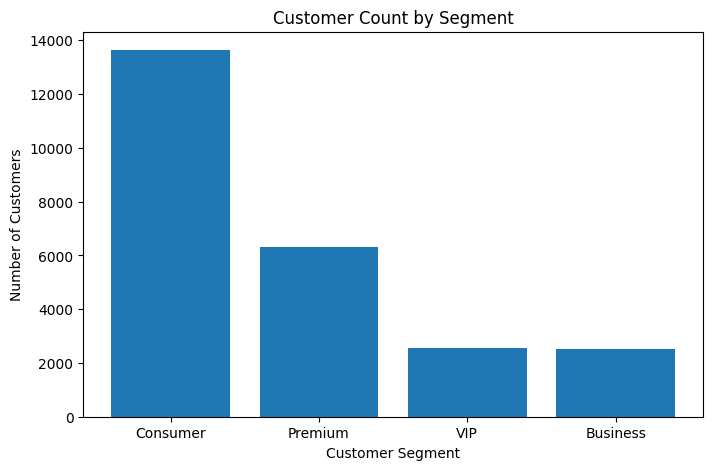

In [0]:
segment_df = (
    df.groupBy("customer_segment")
      .count()
      .orderBy("count", ascending=False)
)

segment_pd = segment_df.toPandas()
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(segment_pd["customer_segment"], segment_pd["count"])

plt.title("Customer Count by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

### 9.2 Gender Distribution

We visualize the number of customers by gender to compare the distribution across different gender groups.


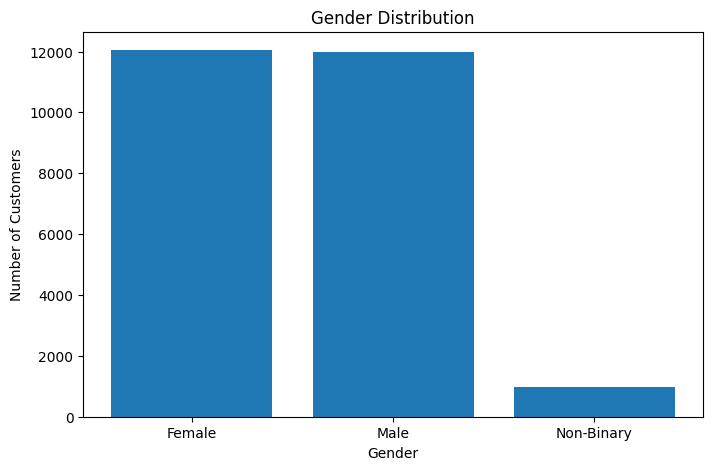

In [0]:
gender_df = (
    df.groupBy("gender")
      .count()
      .orderBy("count", ascending=False)
)

gender_pd = gender_df.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(gender_pd["gender"], gender_pd["count"])

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### 9.3 Customer Distribution by Region

We visualize the number of customers in each region to compare the geographic distribution of customers.


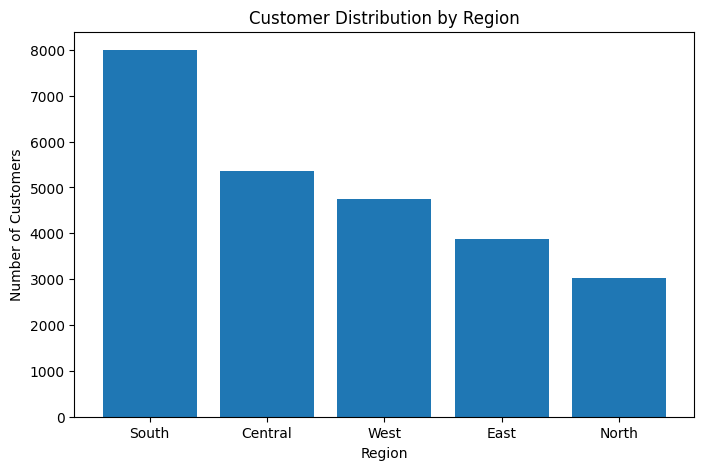

In [0]:
region_df = (
    df.groupBy("region")
      .count()
      .orderBy("count", ascending=False)
)

region_pd = region_df.toPandas()



plt.figure(figsize=(8, 5))

plt.bar(region_pd["region"], region_pd["count"])

plt.title("Customer Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")

plt.show()

### 9.4 Average Acquisition Cost by Customer Segment

We visualize the average customer acquisition cost for each customer segment to compare acquisition costs across different segments.


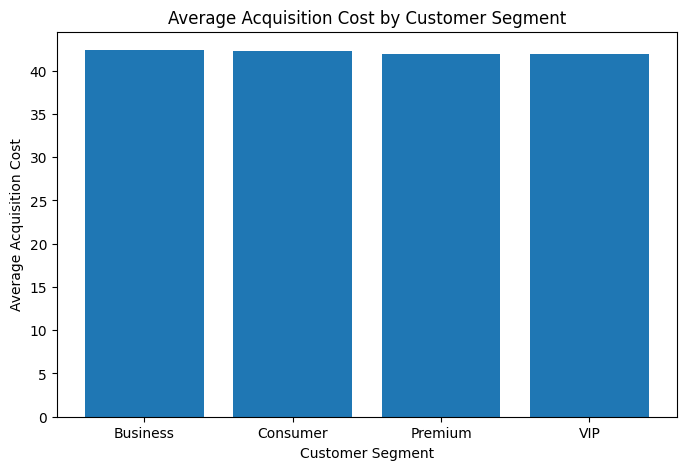

In [0]:
cost_df = (
    df.groupBy("customer_segment")
      .agg(
          f.avg("customer_acquisition_cost").alias("avg_cost")
      )
      .orderBy("avg_cost", ascending=False)
)

cost_pd = cost_df.toPandas()



plt.figure(figsize=(8, 5))

plt.bar(cost_pd["customer_segment"], cost_pd["avg_cost"])

plt.title("Average Acquisition Cost by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Acquisition Cost")

plt.show()

## 10. Key Findings

* The **Consumer** segment has the highest number of customers, with **13,638** customers.
* The **Premium** segment has **6,301** customers, followed by **VIP** with **2,542** and **Business** with **2,519**.
* The dataset contains **14,925 customers from the USA**.
* Among USA customers, **Female** customers represent **7,191**, **Male** customers **7,150**, and **Non-Binary** customers **584**.
* The **Business** segment has the highest average customer age at approximately **46.63 years**.
* Among customers with an acquisition cost above 50, the **Business** segment has the highest average acquisition cost at approximately **65.42**.
* The final customer analysis data was successfully stored as a **Delta table** in Databricks.
* The customer data was partitioned by **region**, with **5 partition files** created.
* The visualizations make it easier to compare customer segments, gender distribution, regions, and average acquisition costs.
* Querying the `South` region demonstrates how the partitioned table can be filtered by region.


## 11. Conclusion

This project demonstrates an end-to-end customer analytics workflow using **PySpark and Databricks**. The project covered data inspection, cleaning, transformation, customer analysis, aggregations, window functions, Spark SQL, Delta table storage, data partitioning, and visualization.

The analysis provided insights into customer segments, demographics, geographic distribution, and customer acquisition costs while applying core Spark concepts to a real-world dataset.
